In [1]:
!git clone https://github.com/VijayaRajasree/Brain-tumor-detection-system.git
%cd Brain-tumor-detection-system

Cloning into 'Brain-tumor-detection-system'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 1), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 795.71 KiB | 3.55 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/Brain-tumor-detection-system


In [2]:
!ls /content

Brain-tumor-detection-system  sample_data


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports Libraries and Tools


In [4]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

Load Datasets


In [18]:
train_dir = '/content/drive/MyDrive/MRI Images/Training'
test_dir = '/content/drive/MyDrive/MRI Images/Testing'

#load and shuffle the train data
train_paths = [] #stores full path
train_labels = [] #stores label


for label in os.listdir(train_dir): #lists all subfolders
  for filename in os.listdir(os.path.join(train_dir, label)): # Renamed 'image' to 'filename'
    train_paths.append(os.path.join(train_dir, label, filename))
    train_labels.append(label)

#shuffling ensures that the order of data does not have bias
train_paths, train_labels = shuffle(train_paths, train_labels)
train_paths

#load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
  for filename in os.listdir(os.path.join(test_dir, label)): # Renamed 'image' to 'filename'
    test_paths.append(os.path.join(test_dir, label, filename))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)
test_paths

['/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0126.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0044.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0283.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0114.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0050.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0290.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0025.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0061.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0247.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0166.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0101.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0353.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0057.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0268.jpg',
 '/content/drive/MyDri

Data Visualization

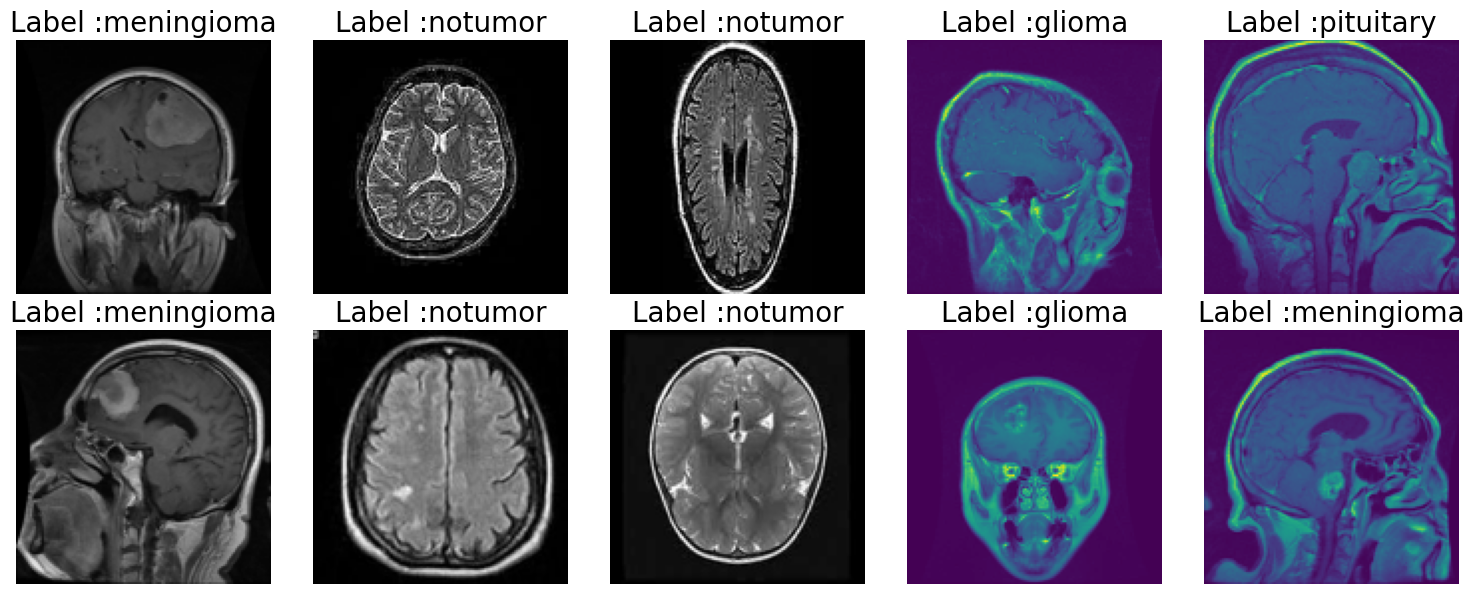

In [6]:
import random
import matplotlib.pyplot as plt

#select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

#create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

#loop through random indices and display images
for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128, 128))

  #display images
  axes[i].imshow(img) #displays image
  axes[i].axis('off') #hides borders
  axes[i].set_title(f"Label :{train_labels[idx]}", fontsize=20)

plt.tight_layout()
plt.show()

Image PreProcessing

In [7]:
# 1.Image Augmentation Function

def augment_image(image):
    """Applies random augmentations to an image."""
    # Convert to PIL image if it's not already
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)

    # Random rotations
    angle = random.randint(-10, 10)
    image = image.rotate(angle)

    # Random flips
    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_TOP_BOTTOM)

    # Random brightness and contrast adjustments
    enhancer = ImageEnhance.Brightness(image)
    image = enhancer.enhance(random.uniform(0.8, 1.2))
    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(random.uniform(0.8, 1.2))

    return np.array(image)


#2. Load images and apply augmentation

def open_images(paths, augment=False):
    """Loads images from given paths and optionally applies augmentation."""
    images = []
    for path in paths:
        try:
            img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
            img = np.array(img)
            if augment:
                img = augment_image(img)
            images.append(img)
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            # Append a placeholder or handle the error as needed
            images.append(None) # Or np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)


    # Filter out None values if any image failed to load

    images = [img for img in images if img is not None]
    return np.array(images)


#3. Encoder labels (Convert label names to integers)

def encode_label(labels):
    """Encodes labels to integers."""
    unique_labels = sorted(list(set(labels)))
    label_map = {label: i for i, label in enumerate(unique_labels)}
    encoded = [label_map[label] for label in labels]
    return np.array(encoded, dtype=np.int64)


#4. Data generator for batching

def datagen(paths, labels, batch_size=12, epochs=1):
    """Generates batches of augmented image data and encoded labels."""
    num_samples = len(paths)
    encoded_labels = encode_label(labels)

    for epoch in range(epochs):
        # Shuffle data at the beginning of each epoch
        paths, encoded_labels = shuffle(paths, encoded_labels)

        for offset in range(0, num_samples, batch_size):
            batch_paths = paths[offset:offset + batch_size]
            batch_labels = encoded_labels[offset:offset + batch_size]

            # Load and augment images
            batch_images = open_images(batch_paths, augment=True)

            # Ensure batch_images is not empty and labels match images length
            if len(batch_images) > 0 and len(batch_images) == len(batch_labels):
                 yield batch_images, batch_labels

In [8]:
IMAGE_SIZE = 128 # Define the image size

In [9]:
# Pick a small subset of your training data for testing
sample_paths = train_paths[:5] #only first 5 images
sample_labels = train_labels[:5]

# Generate one batch from the datagen
generator = datagen(sample_paths, sample_labels, batch_size=5, epochs=1)
batch_images, batch_labels = next(generator) #gives the next batch of images and labels from the generator

print("Batch Images Shape:", batch_images.shape)
print("Batch Labels Shape:", batch_labels.shape)

Batch Images Shape: (5, 128, 128, 3)
Batch Labels Shape: (5,)


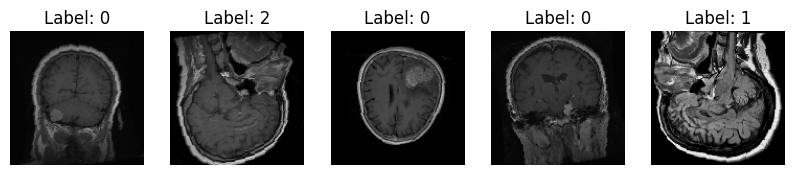

In [10]:
import matplotlib.pyplot as plt

# Show the augmented images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1) # 1 row and 5 cols, and select the (i+1)th position for the next image
    plt.imshow(batch_images[i].astype('uint8')) #converts pixel values to the standard 0-255 integer format
    plt.title(f"Label: {batch_labels[i]}")
    plt.axis('off')
plt.show()


In [11]:
# ------------------------------------------
# Brain Tumor Detection - VGG16 with Checkpoint
# ------------------------------------------

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Input, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt


# ------------------------
# 1. Parameters
# ------------------------
IMAGE_SIZE = 128
BATCH_SIZE = 20
EPOCHS = 5

# 🔴 CHANGE THIS PATH
train_dir = "/content/drive/MyDrive/MRI Images/Training"


# ------------------------
# 2. Data Augmentation
# ------------------------
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation'
)


# ------------------------
# 3. Base Model - VGG16
# ------------------------
base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze layers except last 10
for layer in base_model.layers[:-10]:
    layer.trainable = False

for layer in base_model.layers[-10:]:
    layer.trainable = True


# ------------------------
# 4. Build Model
# ------------------------
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    Flatten(),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(4, activation='softmax')
])


# ------------------------
# 5. Compile Model
# ------------------------
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)


# ------------------------
# 6. Callbacks
# ------------------------
early_stop = EarlyStopping(
    monitor='val_sparse_categorical_accuracy',
    patience=2,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="brain_tumor_vgg16_best.h5",
    monitor='val_sparse_categorical_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)


# ------------------------
# 7. Train Model (RUN ONCE)
# ------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)


# ------------------------
# 8. Load Best Model & Evaluate
# ------------------------
best_model = load_model("brain_tumor_vgg16_best.h5")

loss, acc = best_model.evaluate(val_generator)
print("Best Validation Accuracy:", acc)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.9164 - sparse_categorical_accuracy: 0.6614
Epoch 1: val_sparse_categorical_accuracy improved from -inf to 0.26293, saving model to brain_tumor_vgg16_best.h5


229/229 ━━━━━━━━━━━━━━━━━━━━ 2156s 9s/step - loss: 0.9154 - sparse_categorical_accuracy: 0.6618 - val_loss: 15.9920 - val_sparse_categorical_accuracy: 0.2629
Epoch 2/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.4926 - sparse_categorical_accuracy: 0.8265
Epoch 2: val_sparse_categorical_accuracy improved from 0.26293 to 0.35145, saving model to brain_tumor_vgg16_best.h5


229/229 ━━━━━━━━━━━━━━━━━━━━ 2033s 9s/step - loss: 0.4923 - sparse_categorical_accuracy: 0.8266 - val_loss: 5.5481 - val_sparse_categorical_accuracy: 0.3514
Epoch 3/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.3348 - sparse_categorical_accuracy: 0.8851
Epoch 3: val_sparse_categorical_accuracy improved from 0.35145 to 0.42682, saving model to brain_tumor_vgg16_best.h5


229/229 ━━━━━━━━━━━━━━━━━━━━ 2016s 9s/step - loss: 0.3348 - sparse_categorical_accuracy: 0.8851 - val_loss: 2.8762 - val_sparse_categorical_accuracy: 0.4268
Epoch 4/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.2656 - sparse_categorical_accuracy: 0.9069
Epoch 4: val_sparse_categorical_accuracy improved from 0.42682 to 0.61174, saving model to brain_tumor_vgg16_best.h5


229/229 ━━━━━━━━━━━━━━━━━━━━ 2017s 9s/step - loss: 0.2656 - sparse_categorical_accuracy: 0.9069 - val_loss: 1.0908 - val_sparse_categorical_accuracy: 0.6117
Epoch 5/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.2297 - sparse_categorical_accuracy: 0.9177
Epoch 5: val_sparse_categorical_accuracy improved from 0.61174 to 0.83786, saving model to brain_tumor_vgg16_best.h5


229/229 ━━━━━━━━━━━━━━━━━━━━ 2022s 9s/step - loss: 0.2298 - sparse_categorical_accuracy: 0.9177 - val_loss: 0.5053 - val_sparse_categorical_accuracy: 0.8379
Restoring model weights from the end of the best epoch: 5.


58/58 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step - loss: 0.5159 - sparse_categorical_accuracy: 0.8514
Best Validation Accuracy: 0.8378615379333496


In [12]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential

resnet_model = Sequential([
    ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(128, 128, 3)
    ),
    GlobalAveragePooling2D(),
    Dense(4, activation="softmax")
])

# VERY IMPORTANT: freeze completely
resnet_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
def preprocess_image(img_path):
    img = image.load_img(
        img_path,
        color_mode="grayscale",
        target_size=(128, 128)
    )
    img_array = image.img_to_array(img)
    img_array = np.repeat(img_array, 3, axis=-1)
    img_array = img_array / 255.0
    return np.expand_dims(img_array, axis=0)

In [14]:
def hybrid_safe_predict(img_path,
                        vgg_model,
                        resnet_model,
                        w_vgg=0.7,
                        w_resnet=0.3):

    img = preprocess_image(img_path)

    pred_vgg = vgg_model.predict(img, verbose=0)[0]
    pred_resnet = resnet_model.predict(img, verbose=0)[0]

    final_pred = (w_vgg * pred_vgg) + (w_resnet * pred_resnet)

    idx = np.argmax(final_pred)
    confidence = final_pred[idx] * 100
    label = class_names[idx]

    return label, confidence

In [15]:
def hybrid_test_accuracy(test_images, test_labels, vgg_model, resnet_model,
                         w_vgg=0.7, w_resnet=0.3):

    correct = 0
    total = len(test_images)

    for i in range(total):
        img = preprocess_image(test_images[i])

        pred_vgg = vgg_model.predict(img, verbose=0)[0]
        pred_resnet = resnet_model.predict(img, verbose=0)[0]

        final_pred = (w_vgg * pred_vgg) + (w_resnet * pred_resnet)
        predicted_label = np.argmax(final_pred)

        if predicted_label == test_labels[i]:
            correct += 1

    accuracy = (correct / total) * 100
    return accuracy


In [21]:
encoded_test_labels = encode_label(test_labels)
test_acc = hybrid_test_accuracy(
    test_paths,
    encoded_test_labels,
    model,
    resnet_model
)

print(f"Hybrid Model Test Accuracy: {test_acc:.2f}%")

Hybrid Model Test Accuracy: 80.47%


In [23]:
test_acc = hybrid_test_accuracy(
    test_paths,
    encoded_test_labels,
    model,
    resnet_model
)

print(f"Hybrid Model Test Accuracy: {test_acc:.2f}%")

Hybrid Model Test Accuracy: 80.47%


Train and Val Plots

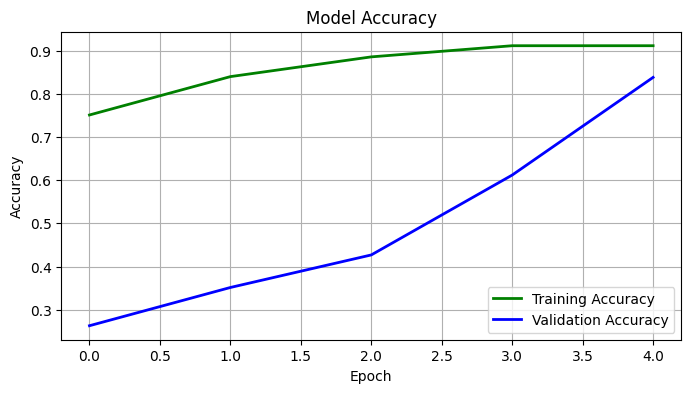

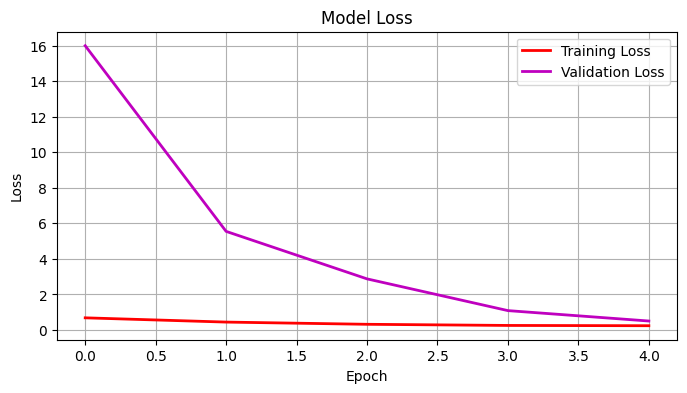

58/58 ━━━━━━━━━━━━━━━━━━━━ 214s 4s/step - loss: 0.4967 - sparse_categorical_accuracy: 0.8335

✅ Final Validation Accuracy: 83.87%


In [24]:
 # ------------------------
# 8. Plot Accuracy (Train vs Val)
# ------------------------
plt.figure(figsize=(8,4))
plt.plot(history.history['sparse_categorical_accuracy'], 'g-', linewidth=2)
plt.plot(history.history['val_sparse_categorical_accuracy'], 'b-', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'], loc='lower right')
plt.grid(True)
plt.show()

# ------------------------
# 9. Plot Loss (Train vs Val)
# ------------------------
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], 'r-', linewidth=2)
plt.plot(history.history['val_loss'], 'm-', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'], loc='upper right')
plt.grid(True)
plt.show()

# ------------------------
# 10. Evaluate on Validation Set
# ------------------------
val_loss, val_acc = model.evaluate(val_generator)
print(f"\n✅ Final Validation Accuracy: {val_acc*100:.2f}%")


Model Classification Report

58/58 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step
📊 Classification Report:

              precision    recall  f1-score   support

      glioma       0.26      0.29      0.28       264
  meningioma       0.25      0.13      0.17       267
     notumor       0.26      0.31      0.29       319
   pituitary       0.31      0.35      0.33       291

    accuracy                           0.28      1141
   macro avg       0.27      0.27      0.27      1141
weighted avg       0.27      0.28      0.27      1141



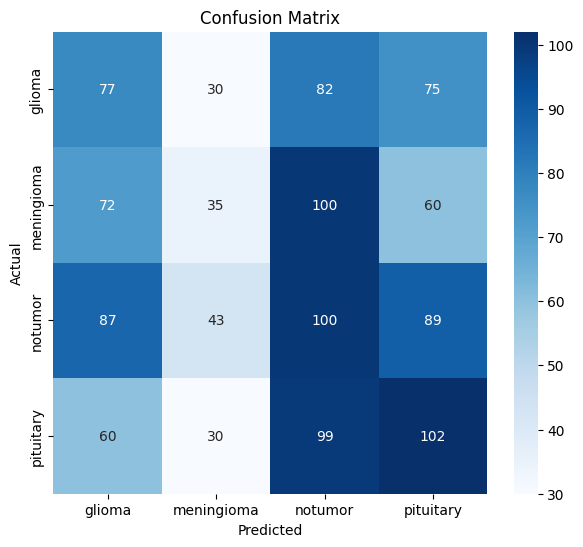

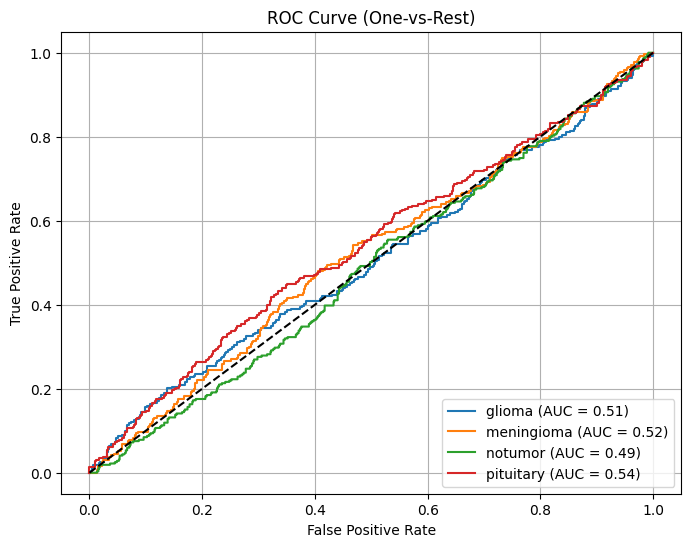

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------
# 1. Get true labels and predictions
# -------------------------------

# Reset the generator before prediction (important!)
val_generator.reset()

# Predict on validation data
pred_probs = model.predict(val_generator)
pred_classes = np.argmax(pred_probs, axis=1)

# True labels
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())  # ['glioma', 'meningioma', 'notumor', 'pituitary']

# -------------------------------
# 2. Classification Report
# -------------------------------
print("📊 Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# -------------------------------
# 3. Confusion Matrix
# -------------------------------
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# -------------------------------
# 4. ROC Curve (for multi-class)
# -------------------------------
from sklearn.preprocessing import label_binarize

# Binarize the labels for ROC calculation
true_binarized = label_binarize(true_classes, classes=range(len(class_labels)))
n_classes = true_binarized.shape[1]

# Compute ROC curve and AUC for each class
plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(true_binarized[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

model = load_model("brain_tumor_vgg16_best.h5")

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

In [26]:
symptoms_info = {
    "glioma": {
        "symptoms": [
            "Persistent headaches",
            "Seizures",
            "Nausea or vomiting",
            "Vision problems"
        ],
        "cognitive": [
            "Memory impairment",
            "Difficulty concentrating",
            "Personality or behavior changes"
        ]
    },
    "meningioma": {
        "symptoms": [
            "Headaches",
            "Blurred vision",
            "Hearing loss",
            "Weakness in limbs"
        ],
        "cognitive": [
            "Slow information processing",
            "Attention difficulties",
            "Mild memory issues"
        ]
    },
    "pituitary": {
        "symptoms": [
            "Hormonal imbalance",
            "Fatigue",
            "Weight changes",
            "Vision disturbances"
        ],
        "cognitive": [
            "Mood swings",
            "Reduced focus",
            "Emotional instability"
        ]
    },
    "notumor": {
        "symptoms": [
            "No abnormal neurological symptoms detected"
        ],
        "cognitive": [
            "Normal cognitive functioning"
        ]
    }
}

In [27]:
def safe_predict(img_path, model, tta_runs=5):
    preds_sum = np.zeros(len(class_names))

    for i in range(tta_runs):
        img = image.load_img(
            img_path,
            color_mode="grayscale",
            target_size=(128, 128)
        )
        img_array = image.img_to_array(img)
        img_array = np.repeat(img_array, 3, axis=-1)

        if i % 2 == 0:
            img_array = np.fliplr(img_array)

        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        preds = model.predict(img_array, verbose=0)
        preds_sum += preds[0]

    avg_preds = preds_sum / tta_runs
    idx = np.argmax(avg_preds)
    confidence = avg_preds[idx] * 100
    label = class_names[idx]

    return label, confidence

In [28]:
def hybrid_detect_display_with_symptoms(img_path,
                                        vgg_model,
                                        resnet_model):

    label, confidence = hybrid_safe_predict(
        img_path, vgg_model, resnet_model
    )

    img = image.load_img(img_path, color_mode="grayscale")

    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    if confidence < 70:
        title = "Prediction – Needs Expert Review"
    else:
        title = f"Prediction: {label} ({confidence:.2f}%)"

    plt.title(title, fontsize=14, color="white", backgroundcolor="black")
    plt.show()

    info = symptoms_info[label]

    print("🧠 Possible Symptoms:")
    for s in info["symptoms"]:
        print(f"  • {s}")

    print("\n🧩 Cognitive / Functional Effects:")
    for c in info["cognitive"]:
        print(f"  • {c}")

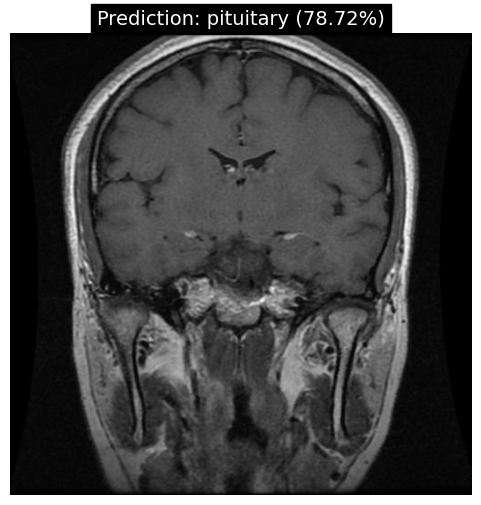

🧠 Possible Symptoms:
  • Hormonal imbalance
  • Fatigue
  • Weight changes
  • Vision disturbances

🧩 Cognitive / Functional Effects:
  • Mood swings
  • Reduced focus
  • Emotional instability


In [35]:
img_path = "/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0071.jpg"

hybrid_detect_display_with_symptoms(
    img_path,
    model,          # VGG16
    resnet_model    # ResNet50
)


Processing image: /content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0126.jpg


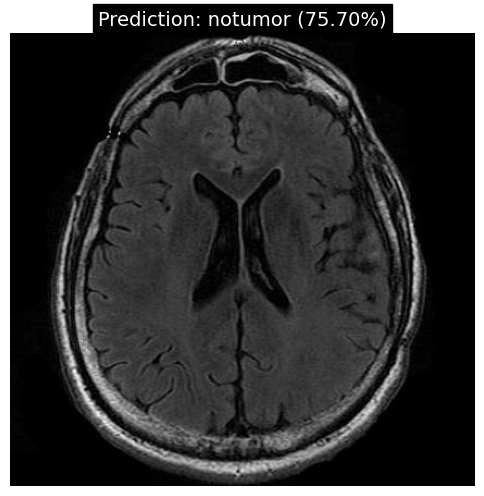

🧠 Possible Symptoms:
  • No abnormal neurological symptoms detected

🧩 Cognitive / Functional Effects:
  • Normal cognitive functioning

Processing image: /content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0044.jpg


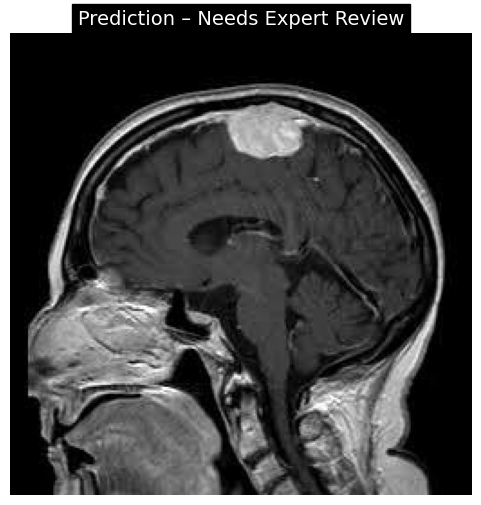

🧠 Possible Symptoms:
  • Headaches
  • Blurred vision
  • Hearing loss
  • Weakness in limbs

🧩 Cognitive / Functional Effects:
  • Slow information processing
  • Attention difficulties
  • Mild memory issues

Processing image: /content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0283.jpg


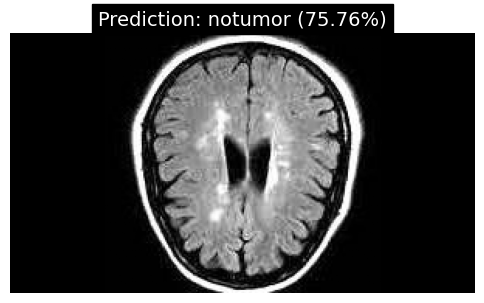

🧠 Possible Symptoms:
  • No abnormal neurological symptoms detected

🧩 Cognitive / Functional Effects:
  • Normal cognitive functioning

Processing image: /content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0114.jpg


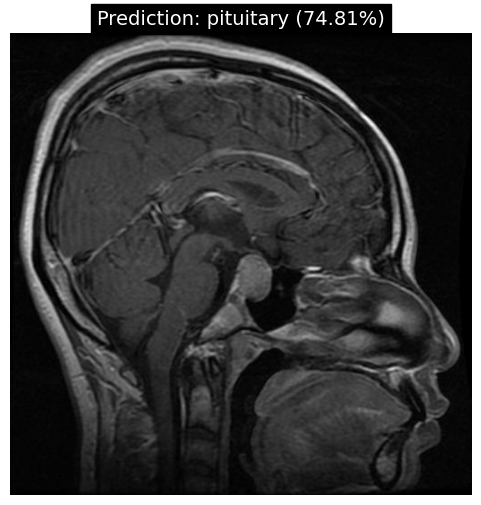

🧠 Possible Symptoms:
  • Hormonal imbalance
  • Fatigue
  • Weight changes
  • Vision disturbances

🧩 Cognitive / Functional Effects:
  • Mood swings
  • Reduced focus
  • Emotional instability

Processing image: /content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0050.jpg


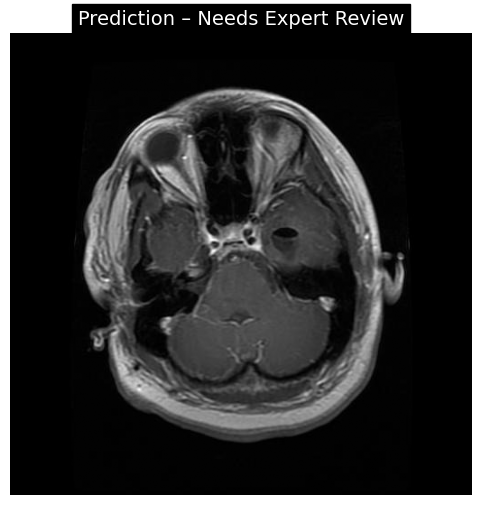

🧠 Possible Symptoms:
  • Hormonal imbalance
  • Fatigue
  • Weight changes
  • Vision disturbances

🧩 Cognitive / Functional Effects:
  • Mood swings
  • Reduced focus
  • Emotional instability


In [38]:
selected_image_paths = test_paths[:5] # Define selected_image_paths, e.g., using the first 5 test images

for img_path in selected_image_paths:
    print(f"\nProcessing image: {img_path}")
    hybrid_detect_display_with_symptoms(
        img_path,
        model,          # VGG16
        resnet_model    # ResNet50
    )